<a href="https://colab.research.google.com/github/Alina-Shrestha/Final/blob/main/6CS012_Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Workshop 1**

**Alina Shrestha**

**2408564**

**Exercise 1**

In [2]:
!pip install pillow

In [ ]:
from PIL import Image

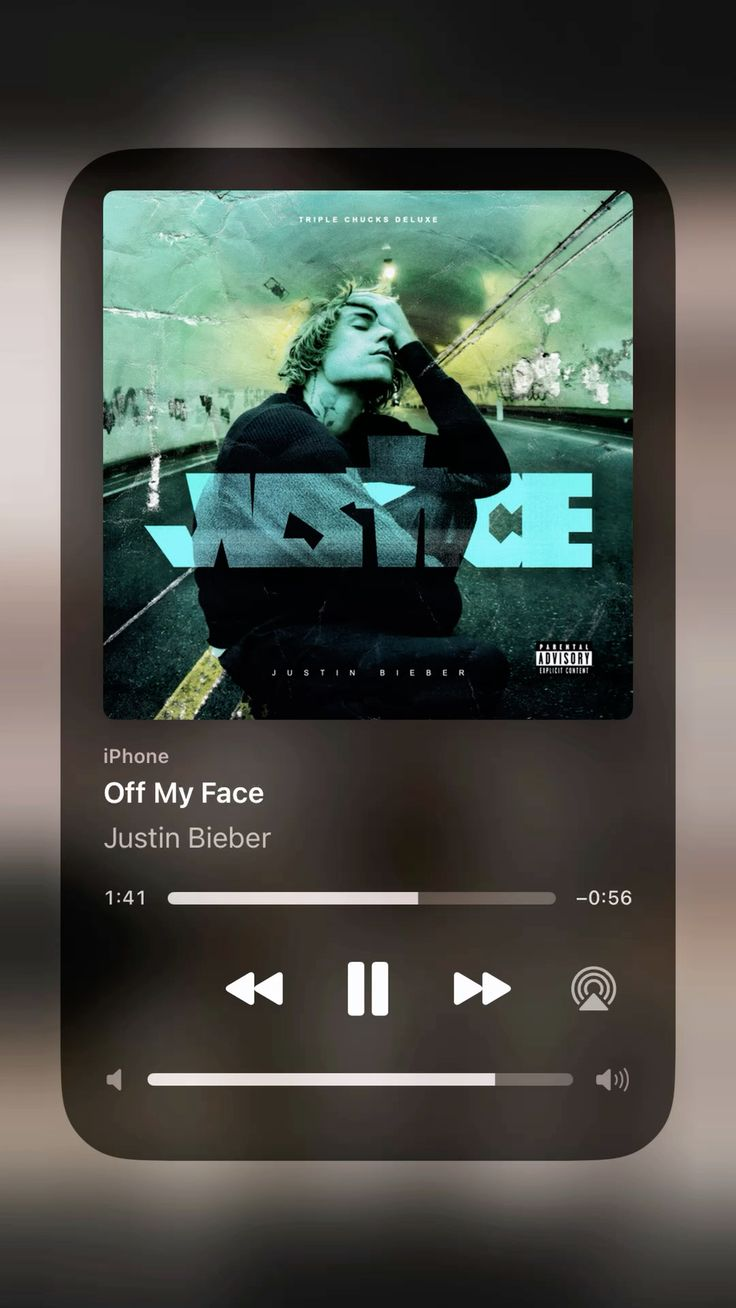

In [6]:
from PIL import Image
from IPython.display import display

# Open the image
image = Image.open("/content/drive/MyDrive/AI and ML/31044e9a56d07609828c8884b5b08321.jpg")

# Display the image in the notebook
display(image)

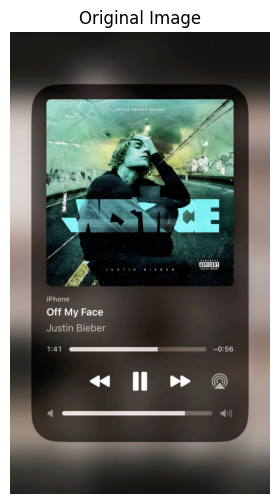

In [20]:
# Import necessary libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Read and display the image
image_path = "/content/drive/MyDrive/AI and ML/31044e9a56d07609828c8884b5b08321.jpg"
img = Image.open(image_path)
plt.figure(figsize=(6,6))
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to NumPy array for processing
img_array = np.array(img)



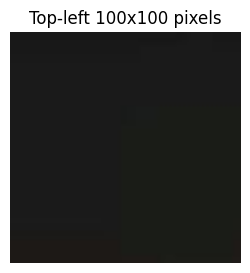

In [9]:
# 2. Display only the top-left corner of 100x100 pixels
top_left = img_array[:100, :100, :]
plt.figure(figsize=(3,3))
plt.title("Top-left 100x100 pixels")
plt.imshow(top_left)
plt.axis('off')
plt.show()

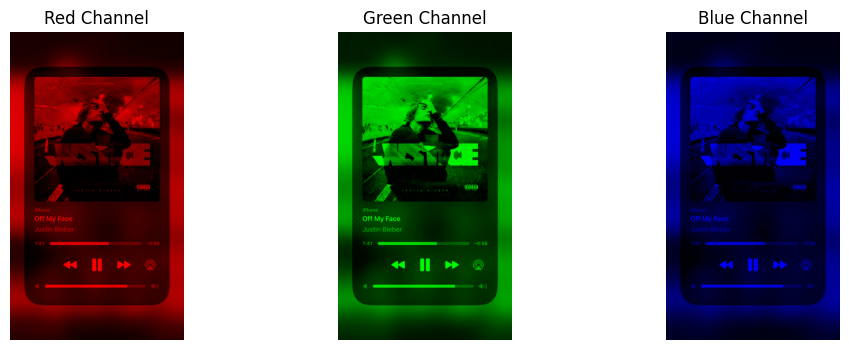

In [11]:
# 3. Show the three color channels (R, G, B)
R = img_array.copy()
R[:, :, 1] = 0  # Remove G
R[:, :, 2] = 0  # Remove B

G = img_array.copy()
G[:, :, 0] = 0  # Remove R
G[:, :, 2] = 0  # Remove B

B = img_array.copy()
B[:, :, 0] = 0  # Remove R
B[:, :, 1] = 0  # Remove G

# Display channels
fig, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].imshow(R)
axs[0].set_title("Red Channel")
axs[1].imshow(G)
axs[1].set_title("Green Channel")
axs[2].imshow(B)
axs[2].set_title("Blue Channel")
for ax in axs:
    ax.axis('off')
plt.show()

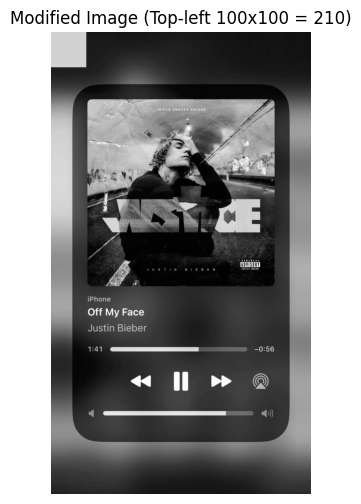

In [30]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Assuming img_array is grayscale (2D)
modified_img = img_array.copy()
modified_img[:100, :100] = 210  # Light gray

# Display the image
plt.figure(figsize=(6,6))
plt.title("Modified Image (Top-left 100x100 = 210)")
plt.imshow(modified_img, cmap='gray')
plt.axis('off')
plt.show()

# Save the image
Image.fromarray(modified_img.astype(np.uint8)).save("/content/exercise1_modified_top_left.jpg")

**Exercise 2**


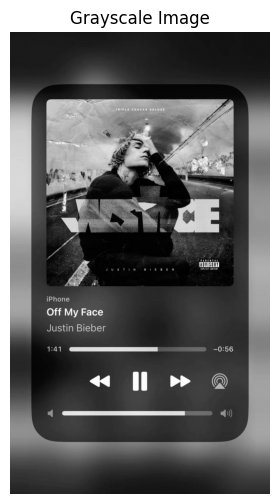

In [19]:
# 1. Load and display a grayscale image
gray_img = Image.open(image_path).convert('L')  # Convert to grayscale
gray_array = np.array(gray_img)

plt.figure(figsize=(6,6))
plt.title("Grayscale Image")
plt.imshow(gray_array, cmap='gray')
plt.axis('off')
plt.show()


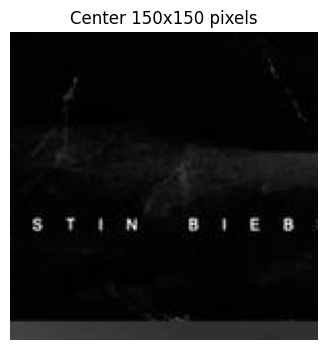

In [14]:

# 2. Extract and display the middle 150x150 pixels
h, w = gray_array.shape
center_crop = gray_array[h//2 - 75:h//2 + 75, w//2 - 75:w//2 + 75]
plt.figure(figsize=(4,4))
plt.title("Center 150x150 pixels")
plt.imshow(center_crop, cmap='gray')
plt.axis('off')
plt.show()

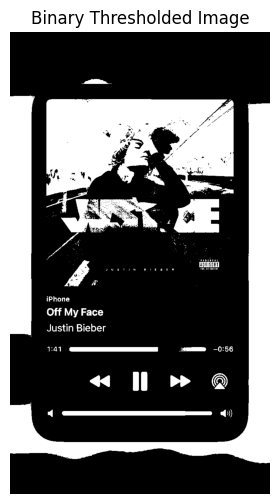

In [16]:
# 3. Apply threshold (binary image)
binary_img = gray_array.copy()
binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255


plt.figure(figsize=(6,6))
plt.title("Binary Thresholded Image")
plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.show()

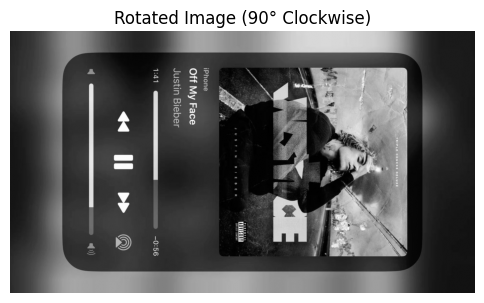

In [17]:
# 4. Rotate image 90 degrees clockwise
rotated_img = gray_img.rotate(-90, expand=True)
plt.figure(figsize=(6,6))
plt.title("Rotated Image (90° Clockwise)")
plt.imshow(rotated_img, cmap='gray')
plt.axis('off')
plt.show()


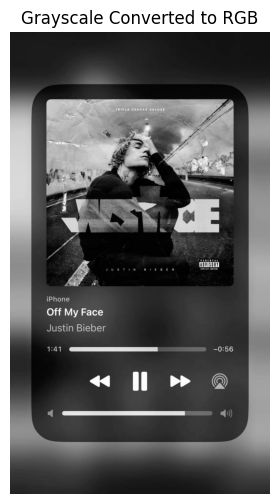

In [31]:

# 5. Convert grayscale to RGB
rgb_from_gray = Image.merge("RGB", (gray_img, gray_img, gray_img))
plt.figure(figsize=(6,6))
plt.title("Grayscale Converted to RGB")
plt.imshow(rgb_from_gray)
plt.axis('off')
plt.show()


binary_img = gray_array.copy()
binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255
Image.fromarray(binary_img.astype(np.uint8)).save("/content/exercise2_binary.jpg")

**Exercise 3 (Image Compression and Decompression using PCA.)**


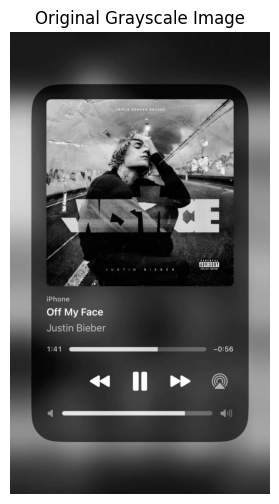

In [21]:


# Import libraries
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load and prepare the image
image_path = "/content/drive/MyDrive/AI and ML/31044e9a56d07609828c8884b5b08321.jpg"
img = Image.open(image_path).convert('L')  # Convert to grayscale
img_array = np.array(img, dtype=float)

plt.figure(figsize=(6,6))
plt.title("Original Grayscale Image")
plt.imshow(img_array, cmap='gray')
plt.axis('off')
plt.show()

# Flatten the image to 2D: rows = height, columns = width
# Actually for images we can keep 2D (pixels as samples), PCA can be applied on columns (width)
X = img_array.copy()

# Center the data (subtract mean of each column)
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean



In [23]:
# 2. Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)  # columns are features



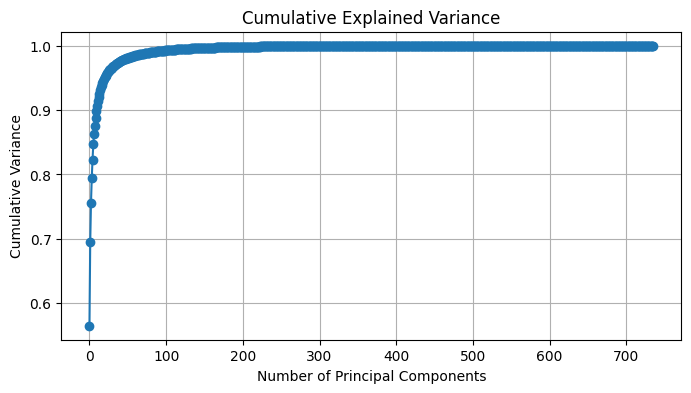

In [24]:
# 3. Eigen decomposition
eig_values, eig_vectors = np.linalg.eigh(cov_matrix)  # For symmetric matrices
# Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eig_values)[::-1]
eig_values = eig_values[sorted_idx]
eig_vectors = eig_vectors[:, sorted_idx]

# Explained variance
explained_variance_ratio = eig_values / np.sum(eig_values)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,4))
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.show()



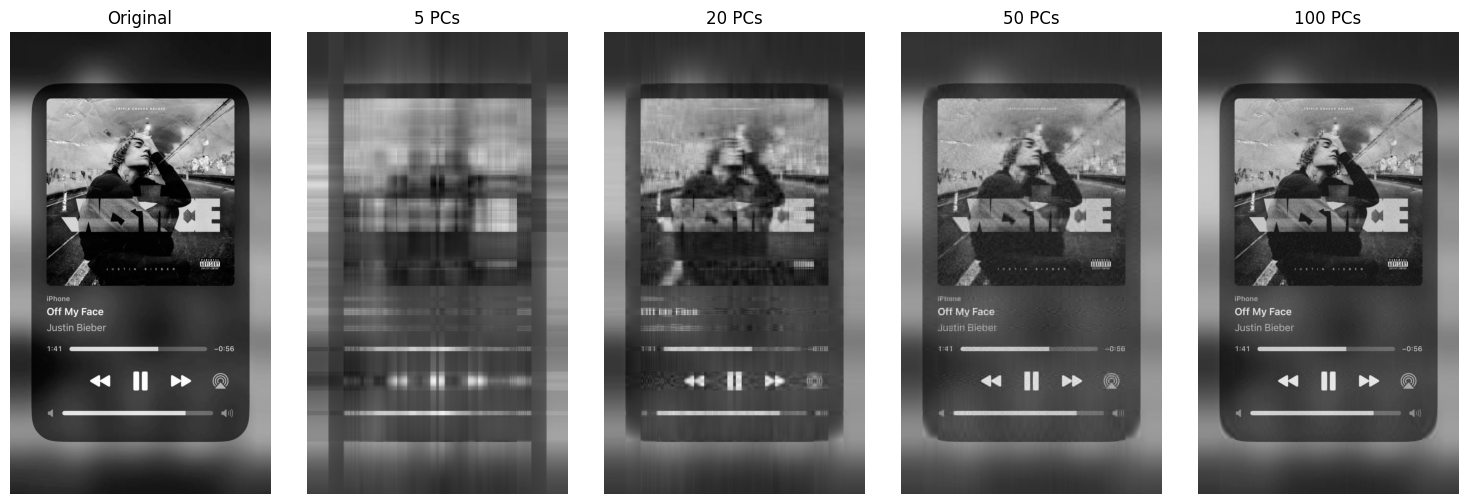

In [32]:
# 4. Reconstruction with different number of PCs
num_pcs_list = [5, 20, 50, 100]  # You can experiment with these values
fig, axs = plt.subplots(1, len(num_pcs_list)+1, figsize=(15,5))

# Show original image
axs[0].imshow(img_array, cmap='gray')
axs[0].set_title("Original")
axs[0].axis('off')

for i, k in enumerate(num_pcs_list):
    # Select top k eigenvectors
    top_eigvecs = eig_vectors[:, :k]

    # Project the centered data to lower dimension
    X_reduced = np.dot(X_centered, top_eigvecs)

    # Reconstruct the image
    X_reconstructed = np.dot(X_reduced, top_eigvecs.T) + X_mean

    axs[i+1].imshow(X_reconstructed, cmap='gray')
    axs[i+1].set_title(f"{k} PCs")
    axs[i+1].axis('off')

plt.tight_layout()
plt.show()


# Assuming X_reconstructed is your NumPy array after PCA
Image.fromarray(np.clip(X_reconstructed, 0, 255).astype(np.uint8)).save("/content/exercise3_reconstructed_50PCs.jpg")